- 허깅페이스 가입
- confirm mail 후 
- 허깅페이스 settings --> Access Tokens 클릭 ---> create token
- https://huggingface.co/inference/get-started
- 상기 링크 코드 복사해서 셀 실행시켜보기



### <span style="color: Gold"> Your first LLM call

In [ ]:
import os
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv() 


client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

completion = client.chat.completions.create(
    model="moonshotai/Kimi-K2-Instruct-0905",
    messages=[
        {
            "role": "user",
            "content": "Generate a list of 10 interesting facts about space."
        }
    ],
)

print(completion.choices[0].message)

ChatCompletionMessage(content='1. A day on Venus (one full rotation) lasts longer than its year (one full orbit around the Sun).  \n2. Saturn’s average density is so low that, if you could find a bathtub big enough, the planet would float.  \n3. There’s a giant cloud of alcohol—enough to make 400 trillion trillion pints of beer—near the constellation Aquila.  \n4. Footprints on the Moon will last millions of years because there’s no wind or water to erode them.  \n5. Neutron stars are so dense that a teaspoon of their material would weigh about as much as Mount Everest.  \n6. The Milky Way and Andromeda galaxies are on a collision course; they’ll merge into one giant galaxy in ~4.5 billion years.  \n7. Space is silent—sound waves need a medium to travel, and the near-vacuum of space provides none.  \n8. Jupiter’s Great Red Spot is a storm wider than Earth that has been raging for at least 350 years.  \n9. Cosmic “time dilation” means that light from the Sun’s core takes ~100,000 years 

### <span style="color: Gold"> Generate an image


In [ ]:
import os
from huggingface_hub import InferenceClient
from dotenv import load_dotenv
load_dotenv() 


client = InferenceClient(
    provider="together",
    api_key=os.environ["HF_TOKEN"],
)

# output is a PIL.Image object
image = client.text_to_image(
    "A futuristic city skyline at sunset",
    model="black-forest-labs/FLUX.1-dev",
)

image
# image.show() # .py 파일로 실행시 이 코드 사용할 것



### <span style="color: Gold"> 허깅페이스의 무료 tier로 사용 : 런팟 사용
- https://huggingface.co/black-forest-labs/FLUX.1-dev
- gate repos ~ 클릭하고나면 (해당모델에 대해서 access 신청) --> 바로 승인 또는 몇시간 또는 며칠뒤에 승인되는 경우가 있음
- setting에 gated Repositories에 들어가면 있음
- 허깅페이스에 로그인 (브라우저 로그인 X)
    - 로그인 하려면 pip install huggingface_hub 하고나서
        - CLI (터미널에서 로그인) : huggingface_cli logint --> 토큰 입력
        - 코드상에서 로그인 : 
        ``` python
            from dotenv import load_dotenv
            load_dotenv() 
            from huggingface_hub import login
            login(token=os.getenv('HF_TOKEN')) 

## <span style="color: Gold"> RUNPOD 사용

#### <span style="color: Gold"> RUNPOD 1 : black-forest-labs/FLUX.1-dev
- 강사님이 runpod 돌린 것 : 1_2_T_runpod_black_forest_labsFLUX.1_dev.ipynb 

In [ ]:
# %pip install -U diffusers
# %pip install huggingface_hub
# %pip install hf_xet


In [ ]:
# 원본 코드 --> runpot에서 돌리기
# 런팟에서 HF_TOKEN 저장하기 
# pot 시작하고 - 점3개 부분 눌러서 - editpot 클릭해서 거기서 환경변수 추가하기
import torch
import os
from diffusers import FluxPipeline
from dotenv import load_dotenv
load_dotenv() 
from huggingface_hub import login
login(token=os.getenv('HF_TOKEN'))


pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-dev", torch_dtype=torch.bfloat16) # 원본
pipe.enable_model_cpu_offload() #save some VRAM by offloading the model to CPU. Remove this if you have enough GPU power

prompt = "A cat holding a sign that says hello world"
image = pipe(
    prompt,
    height=1024,
    width=1024,
    guidance_scale=3.5,
    num_inference_steps=50,
    max_sequence_length=512,
    generator=torch.Generator("cpu").manual_seed(0)
).images[0]
image.save("flux-dev.png")


#### <span style="color: Gold"> RUNPOD 2 & colab : 
- LoRA_QLoRA_Finetuning : stabilityai/stable-diffusion-xl-base-1.0
- 추론 진행
- 강사님 파일 : 1_3_T_runpod_colab_lora_finetune.ipynb



```text

- 파일 저장 후 다시 재실행 때 안되는것은 runpod이 변경되어서 그럴수있음. 그럼 라이브러리 재설치 필요

- SDXL에서 LoRA config는 어디에 적용되나?
    SDXL
    ├── UNet            ← 🎯 LoRA 주 타겟
    ├── Text Encoder 1  ← 선택
    ├── Text Encoder 2  ← 선택
    └── VAE             ← 보통 제외


* LoRA
- Base model: FP16 / FP32
- Adapter: FP16
- GPU 메모리 사용 큼

* QLoRA
- Base model: 4bit quantized
- Adapter: FP16
- GPU 메모리 극단적 절약

❗ 하지만 중요한 점:
🔥 QLoRA도 LoRA config 자체는 똑같다


 ```

- LoRA 설정
    - u-net : 인코더, 디코더가 합쳐져 있는 것으로 proj_in 인코더, proj_out 디코더
    - ff.net ---> Feed Forward Network : 출력 계층

- 학습설정 코드
    - 데이터기반이 아니라, 구조를 바꿔서.. ??

- VAE는 학습을 하지 않음
- 

## <span style="color: Gold"> CPU 사용 =====

#### <span style="color: Gold"> cpu 1 : stable-diffusion-v1-5

In [ ]:
# %pip install -U diffusers torch transformers gguf
# %pip install huggingface_hub python-dotenv

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


🔽 Loading Stable Diffusion 1.5 (~4GB)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


✅ Model loaded
🎨 Generating image...


  0%|          | 0/35 [00:00<?, ?it/s]

✅ Image saved


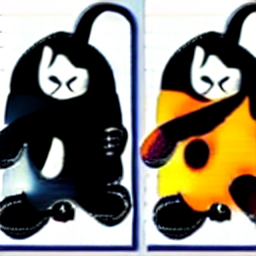

In [4]:
############# 상기 코드 CPU 돌려보려고 코드 수정
# RAM이 부족하거나 다운로드 용량이 부담된다면 위의 GGUF 코드를 사용하세요! 🚀

import torch
import os
from diffusers import StableDiffusionPipeline
from dotenv import load_dotenv
from huggingface_hub import login

# 환경 설정
load_dotenv()
login(token=os.getenv('HF_TOKEN'))
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

print("🔽 Loading Stable Diffusion 1.5 (~4GB)")

# SD 1.5 로딩
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float32,
    safety_checker=None,  # CPU 환경에서는 비활성화
)

# 메모리 최적화
pipe.enable_attention_slicing()  # 메모리 절약
# pipe.enable_model_cpu_offload()  # 선택사항

print("✅ Model loaded")
print("🎨 Generating image...")



# =====================
# 프롬프트
# =====================

# stable-diffusion-v1.5 모델은 기본적으로 얼굴 중심 모델

prompt = (
    "a single ginger cat, full body, standing, front view, "
    "holding a cardboard sign with both paws, "
    "simple flat illustration, white background"
)


# stable-diffusion-v1.5 모델은 negative prompt 가 필수
negative_prompt = (
    "close up, face only, head only, portrait, split screen, "
    "two cats, multiple cats, cropped, zoomed in, "
    "human, people, blurry, low quality, watermark"
)

image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    height=256,
    width=256,
    num_inference_steps=35,
    guidance_scale=9.0,   # 프롬프트 말을 얼마나 세게 들을지 설정하는 값. # 3~5: 자유도 높음 7~9: 프름프토 꽤 잘따라 12~15: 그림이 딱딱, 왜곡, 노이즈 증가
    generator=torch.Generator("cpu").manual_seed(42)
).images[0]

image.save("output20251217_2.png")
print("✅ Image saved")
image

#### <span style="color: Gold"> cpu 2 : hakurei/waifu-diffusion

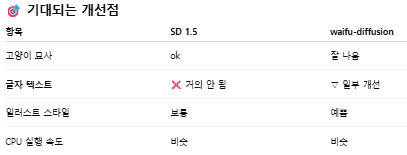

In [ ]:
# hakurei/waifu-diffusion 모델


import torch
import os
from diffusers import StableDiffusionPipeline
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
login(token=os.getenv("HF_TOKEN"))

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

print("🚀 Loading waifu-diffusion (CPU)")

pipe = StableDiffusionPipeline.from_pretrained(
    "hakurei/waifu-diffusion",
    dtype=torch.float32,
    safety_checker=None,
)

pipe.enable_attention_slicing()

prompt = "a cute cat holding a sign that says 'hello world', simple illustration"

negative_prompt = "blurry, distorted, bad anatomy, cropped, head only"

image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    height=256,
    width=256,
    num_inference_steps=30,
    guidance_scale=8.0,
    generator=torch.Generator("cpu").manual_seed(42),
).images[0]

image.save("output20251217_2.png")
print("✅ Done")
image

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


🚀 Loading waifu-diffusion (CPU)


model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

c:\Users\playdata2\miniconda3\envs\LLM312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\playdata2\.cache\huggingface\hub\models--hakurei--waifu-diffusion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

...

Keyword arguments {'dtype': torch.float32} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Done: waifu_cat_hello.png


#### <span style="color: Gold"> cpu 3 : CPU용 코드 (DreamShaper-8)

- SD 1.5 기반
- 리얼 + 세미리얼
- 사람 + 물건 들기 성공률 높음
- 약 4~5GB
- CPU 가능 (느리지만 안정)


In [4]:
import torch
import os
from diffusers import StableDiffusionPipeline
from dotenv import load_dotenv
from huggingface_hub import login

# 환경 설정
load_dotenv()
login(token=os.getenv("HF_TOKEN"))

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

print("🔽 Loading DreamShaper 8 (CPU)")

pipe = StableDiffusionPipeline.from_pretrained(
    "Lykon/dreamshaper-8",
    dtype=torch.float32,
    safety_checker=None,
)

# CPU 메모리 최적화
pipe.enable_attention_slicing()

print("✅ Model loaded")
print("🎨 Generating image...")

# =====================
# 프롬프트
# =====================
prompt = (
    "a single young woman, "
    "eating noodle with chopsticks in the left hand, "
    "clean studio lighting, white background, "
    "professional product photo, realistic"
)

negative_prompt = (
    "two people, extra hands, extra fingers, deformed hands, "
    "bad anatomy, blurry, cropped, close up face, watermark, text"
)

image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    height=512,
    width=512,
    num_inference_steps=35,
    guidance_scale=7.5,
    generator=torch.Generator("cpu").manual_seed(42)
).images[0]

image.save("eating_model.png")
print("✅done")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


🔽 Loading DreamShaper 8 (CPU)


Keyword arguments {'dtype': torch.float32} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


✅ Model loaded
🎨 Generating image...


  0%|          | 0/35 [00:00<?, ?it/s]

✅done
